In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    f1_score
)
from scipy.stats import ttest_rel

import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

d:\PPTI 15 ARTEMIS\Semester 8 (Skripsi)\TAM UTAUT\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

df = pd.read_csv("outputs_indobert.csv")
df_berta = pd.read_csv("outputs_indoroberta.csv")
# fitur
X = df[["PE","EE","SI","FC"]]
X2 = df_berta[["PE","EE","SI","FC"]]
# target
y = df["sentiment"]
y2 = df_berta["sentiment"]

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
y2_encoded = le.fit_transform(y2)

In [4]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X, y_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [5]:
model.fit(X2, y2_encoded)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [6]:
import shap

explainer = shap.Explainer(model, X)
shap_values = explainer(X)

In [7]:
explainer2 = shap.Explainer(model, X2)
shap_values2 = explainer(X2)

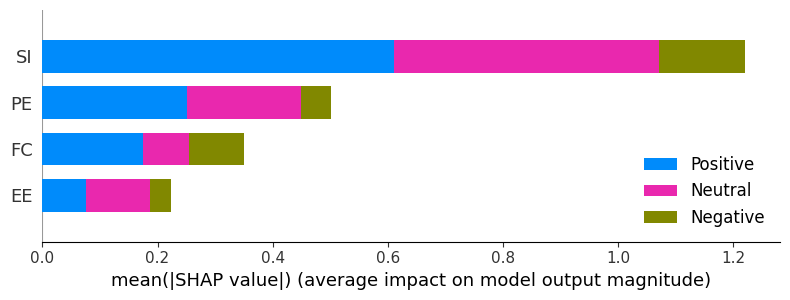

In [8]:
class_names = ["Negative", "Neutral", "Positive"]

shap.summary_plot(
    shap_values,
    X,
    plot_type="bar",
    class_names=class_names
)

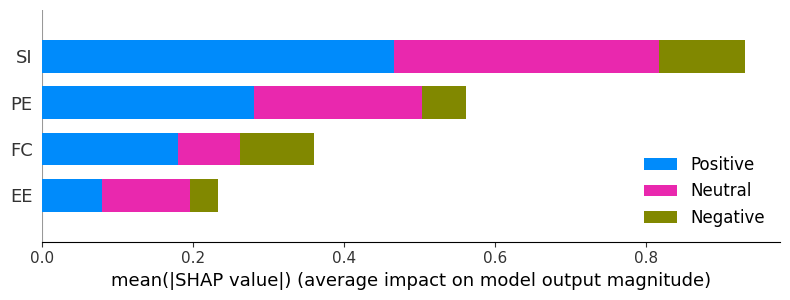

In [9]:
shap.summary_plot(
    shap_values2,
    X2,
    plot_type="bar",
    class_names=class_names
)

In [10]:
labels = ["negative", "neutral", "positive"]
bert = pd.read_csv("outputs_indobert.csv")

roberta = pd.read_csv("outputs_indoroberta.csv")
label = pd.read_csv("comment_wlabel_sentiment.csv")

In [11]:

label["comment"] = label["comment"].str.strip()
bert["comment"] = bert["comment"].str.replace(",+", "", regex=True).str.strip()
roberta["comment"] = roberta["comment"].str.replace(",+", "", regex=True).str.strip()

In [12]:
def clean_text(x):
    return (
        str(x)
        .lower()
        .replace(",", "")
        .strip()
    )

label["comment"] = label["comment"].apply(clean_text)
bert["comment"] = bert["comment"].apply(clean_text)
roberta["comment"] = roberta["comment"].apply(clean_text)

In [13]:
print(bert.columns)

Index(['comment', 'sentiment', 'PE', 'EE', 'SI', 'FC'], dtype='str')


In [14]:
df = label.merge(
    bert[["comment","sentiment"]].rename(columns={"sentiment":"bert_pred"}),
    on="comment",
    how="inner"
).merge(
    roberta[["comment","sentiment"]].rename(columns={"sentiment":"roberta_pred"}),
    on="comment",
    how="inner"
)

In [15]:
df["label"] = pd.to_numeric(df["label"], errors="coerce")

In [16]:
df = df.dropna(subset=["label"])

In [17]:
df["label"] = df["label"].astype(int)

In [18]:
label_map = {
    0.0: "negative",
    1.0: "neutral",
    2.0: "positive"
}

df["label"] = df["label"].map(label_map)

In [19]:
print(label["label"].unique())
print(label["label"].isna().sum())

[ 1.  0.  2. nan]
1


In [20]:
print(df.head())
print(df["label"].unique)

                                             comment    label bert_pred  \
0                                    harus pake vpn?  neutral   neutral   
1                      pikiran nya udah jaaht duluan  neutral  negative   
2  bang mau nanya aku ada tugas video ai disuruh ...  neutral   neutral   
3                                                  ?  neutral   neutral   
4                                                  ?  neutral   neutral   

  roberta_pred  
0      neutral  
1      neutral  
2      neutral  
3      neutral  
4      neutral  
<bound method Series.unique of 0        neutral
1        neutral
2        neutral
3        neutral
4        neutral
          ...   
10809    neutral
10810    neutral
10811    neutral
10812    neutral
10813    neutral
Name: label, Length: 10805, dtype: str>


In [21]:
print(df.dtypes)

comment         str
label           str
bert_pred       str
roberta_pred    str
dtype: object


In [22]:
cm_bert = confusion_matrix(df["label"], df["bert_pred"])
cm_roberta = confusion_matrix(df["label"], df["roberta_pred"])

print("Confusion Matrix IndoBERT")
print(cm_bert)

print("\nConfusion Matrix IndoRoBERTa")
print(cm_roberta)

Confusion Matrix IndoBERT
[[ 224   15    1]
 [  59 7886   92]
 [   4  217 2307]]

Confusion Matrix IndoRoBERTa
[[ 216   23    1]
 [  75 7920   42]
 [   2  217 2309]]


In [23]:
print("\nClassification Report IndoBERT")
print(classification_report(df["label"], df["bert_pred"]))

print("\nClassification Report IndoRoBERTa")
print(classification_report(df["label"], df["roberta_pred"]))


Classification Report IndoBERT
              precision    recall  f1-score   support

    negative       0.78      0.93      0.85       240
     neutral       0.97      0.98      0.98      8037
    positive       0.96      0.91      0.94      2528

    accuracy                           0.96     10805
   macro avg       0.90      0.94      0.92     10805
weighted avg       0.96      0.96      0.96     10805


Classification Report IndoRoBERTa
              precision    recall  f1-score   support

    negative       0.74      0.90      0.81       240
     neutral       0.97      0.99      0.98      8037
    positive       0.98      0.91      0.95      2528

    accuracy                           0.97     10805
   macro avg       0.90      0.93      0.91     10805
weighted avg       0.97      0.97      0.97     10805



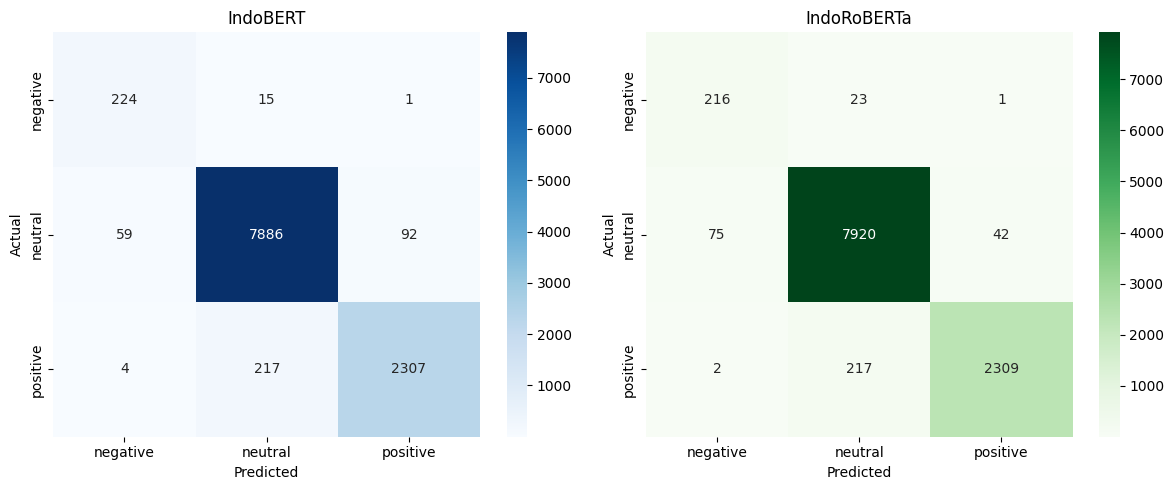

In [24]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(cm_bert, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, ax=axes[0])

axes[0].set_title("IndoBERT")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(cm_roberta, annot=True, fmt="d", cmap="Greens",
            xticklabels=labels, yticklabels=labels, ax=axes[1])

axes[1].set_title("IndoRoBERTa")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [25]:
labels = ["negative","neutral","positive"]

cm_bert_df = pd.DataFrame(cm_bert, index=labels, columns=labels)
cm_roberta_df = pd.DataFrame(cm_roberta, index=labels, columns=labels)

print("\nConfusion Matrix IndoBERT")
print(cm_bert_df)

print("\nConfusion Matrix IndoRoBERTa")
print(cm_roberta_df)


Confusion Matrix IndoBERT
          negative  neutral  positive
negative       224       15         1
neutral         59     7886        92
positive         4      217      2307

Confusion Matrix IndoRoBERTa
          negative  neutral  positive
negative       216       23         1
neutral         75     7920        42
positive         2      217      2309


In [26]:
acc_bert = accuracy_score(
    df["label"],
    df["bert_pred"]
)

acc_roberta = accuracy_score(
    df["label"],
    df["roberta_pred"]
)

In [27]:
from sklearn.metrics import f1_score

f1_bert = f1_score(
    df["label"],
    df["bert_pred"],
    average="macro"
)

f1_roberta = f1_score(
    df["label"],
    df["roberta_pred"],
    average="macro"
)

In [28]:
results = pd.DataFrame({

"Model":["IndoBERT","IndoRoBERTa"],

"Accuracy":[acc_bert,acc_roberta],

"F1":[f1_bert,f1_roberta]

})

results

,Model,Accuracy,F1
0,IndoBERT,0.964091,0.920890
1,IndoRoBERTa,0.966682,0.911592


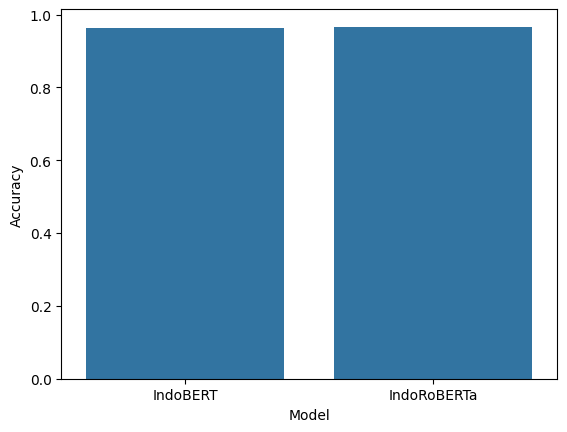

In [29]:
sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.show()

## STATISTICAL SIGNIFICANCE TEST | ex: p < 0.05 -> significant difference

In [30]:
sentiment_to_num = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["bert_num"] = df["bert_pred"].map(sentiment_to_num)
df["roberta_num"] = df["roberta_pred"].map(sentiment_to_num)

In [31]:
from scipy.stats import ttest_rel

t_stat, p_value = ttest_rel(
    df["bert_num"],
    df["roberta_num"]
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 4.976567047199934
p-value: 6.5719644326375e-07


## SHAP EXPLAINABILITY

In [32]:
df_bert = pd.read_csv("outputs_indobert.csv")

X_bert = df_bert[["PE","EE","SI","FC"]]
y_bert = df_bert["sentiment"]

le_bert = LabelEncoder()
y_bert_enc = le_bert.fit_transform(y_bert)

model_bert = LogisticRegression(max_iter=1000)
model_bert.fit(X_bert, y_bert_enc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

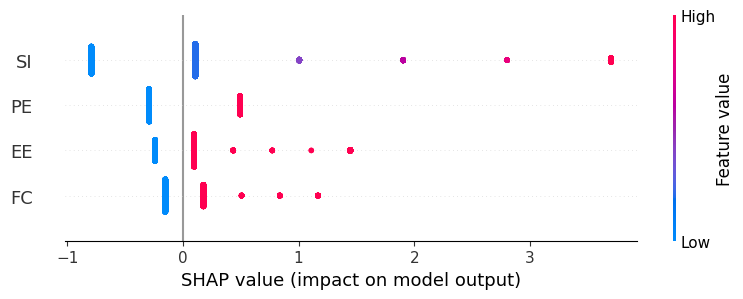

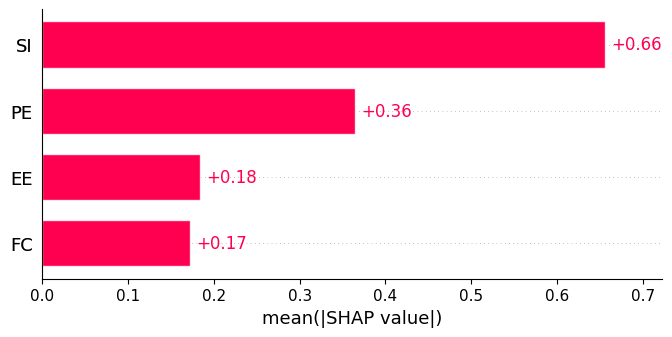

In [33]:
explainer_bert = shap.Explainer(model_bert, X_bert)
shap_values_bert = explainer_bert(X_bert)

# pilih class (misalnya positive = index 2)
class_idx = 2

# SUMMARY PLOT
shap.summary_plot(shap_values_bert.values[:,:,class_idx], X_bert)

# BAR PLOT
shap.plots.bar(shap_values_bert[:,:,class_idx])

In [34]:
# total pengaruh SHAP
impact = np.abs(shap_values_bert.values).sum(axis=(1,2))

# confidence model
probs = model_bert.predict_proba(X_bert)
confidence = probs.max(axis=1)

# simpan ke dataframe
df_bert["impact"] = impact
df_bert["confidence"] = confidence

In [35]:
# paling yakin
best_conf_idx = df_bert["confidence"].idxmax()

# paling impactful
best_impact_idx = df_bert["impact"].idxmax()

selected_indices = [best_conf_idx, best_impact_idx]

In [36]:
# idx = 0
# shap.plots.waterfall(shap_values_bert[idx,:,class_idx])

In [37]:
selected_indices = []

for label in df_bert["sentiment"].unique():
    subset = df_bert[df_bert["sentiment"] == label]
    idx = subset.sort_values("confidence", ascending=False).iloc[0].name
    selected_indices.append(idx)

KOMENTAR:
temen-temen kantor udah pada pake,masa saya nggak. gokil

SENTIMENT: neutral
CONFIDENCE: 0.99


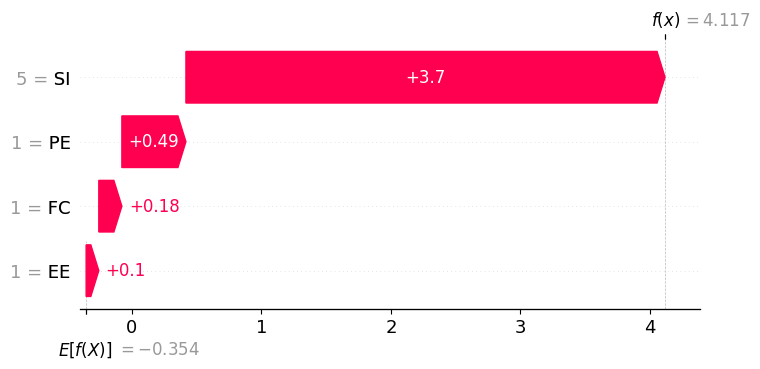

KOMENTAR:
rekomendasi dari komunitas ai ini emang tidak pernah gagal. output-nya kurang akurat buat kebutuhan profesional. parah sih

SENTIMENT: negative
CONFIDENCE: 0.99


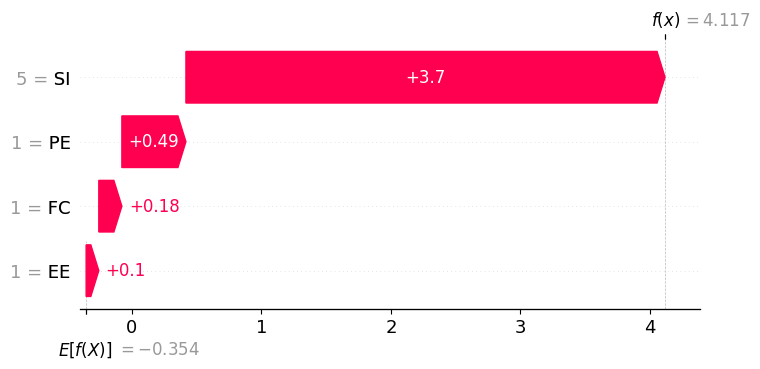

KOMENTAR:
cara pakainya gampang banget,gak perlu tutorial. sangat efektif untuk meningkatkan produktivitas kerja.

SENTIMENT: positive
CONFIDENCE: 0.999


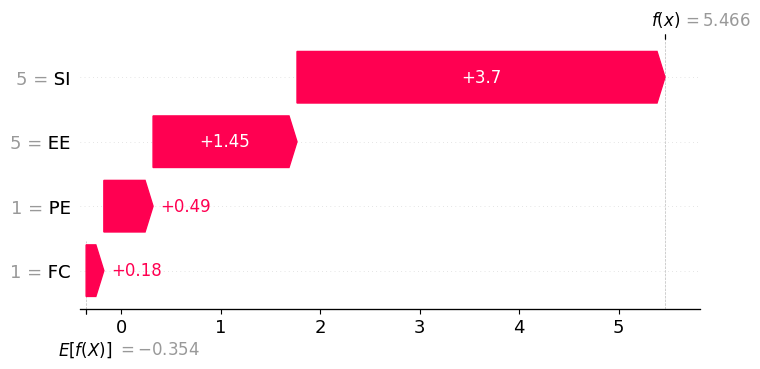

In [38]:
# tentukan class (misalnya positive)
class_idx = list(le_bert.classes_).index("positive")

for idx in selected_indices:
    print("="*60)
    print("KOMENTAR:")
    print(df_bert.loc[idx, "comment"])
    print()
    print("SENTIMENT:", df_bert.loc[idx, "sentiment"])
    print("CONFIDENCE:", round(df_bert.loc[idx, "confidence"], 3))
    print("="*60)
    
    shap.plots.waterfall(shap_values_bert[idx,:,class_idx])

In [39]:
df_roberta = pd.read_csv("outputs_indoroberta.csv")

X_roberta = df_roberta[["PE","EE","SI","FC"]]
y_roberta = df_roberta["sentiment"]

le_roberta = LabelEncoder()
y_roberta_enc = le_roberta.fit_transform(y_roberta)

model_roberta = LogisticRegression(max_iter=1000)
model_roberta.fit(X_roberta, y_roberta_enc)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

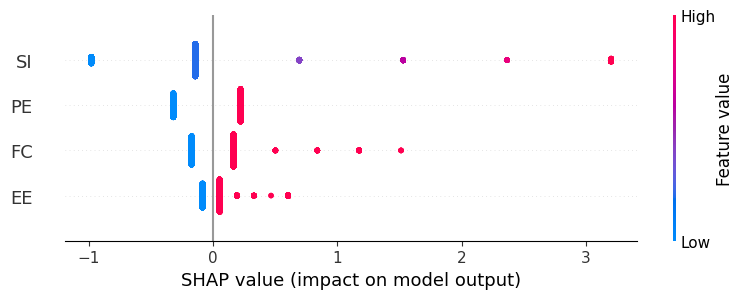

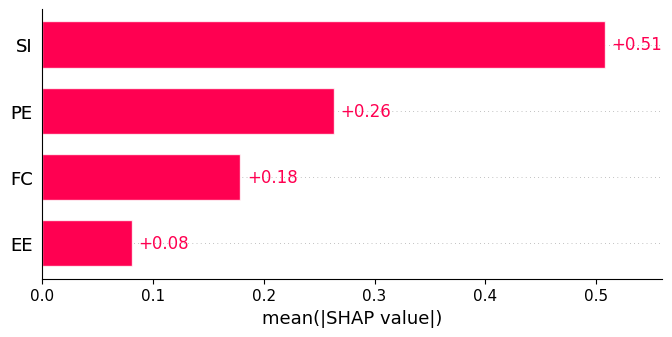

In [40]:
explainer_roberta = shap.Explainer(model_roberta, X_roberta)
shap_values_roberta = explainer_roberta(X_roberta)

# class index (biasanya sama: positive = 2)
class_idx = 2

# SUMMARY PLOT
shap.summary_plot(shap_values_roberta.values[:,:,class_idx], X_roberta)

# BAR PLOT
shap.plots.bar(shap_values_roberta[:,:,class_idx])

In [41]:
# total pengaruh SHAP
impact_roberta = np.abs(shap_values_roberta.values).sum(axis=(1,2))

# confidence model
probs_roberta = model_roberta.predict_proba(X_bert)
confidence_roberta = probs.max(axis=1)

# simpan ke dataframe
df_roberta["impact"] = impact
df_roberta["confidence"] = confidence

In [42]:
# # paling yakin
# best_conf_idx_roberta = df_roberta["confidence"].idxmax()

# # paling impactful
# best_impact_idx_roberta = df_roberta["impact"].idxmax()

# selected_indices_roberta = [best_conf_idx_roberta, best_impact_idx_roberta]

In [43]:
# idx = 0
# shap.plots.waterfall(shap_values_roberta[idx,:,class_idx])

In [44]:
# selected_indices = []

# for label in df_roberta["sentiment"].unique():
#     subset = df_roberta[df_roberta["sentiment"] == label]
#     idx = subset.sort_values("confidence", ascending=False).iloc[0].name
#     selected_indices.append(idx)

In [45]:
# # tentukan class (misalnya positive)
# class_idx = list(le_roberta.classes_).index("positive")

# for idx in selected_indices:
#     print("="*60)
#     print("KOMENTAR:")
#     print(df_roberta.loc[idx, "comment"])
#     print()
#     print("SENTIMENT:", df_roberta.loc[idx, "sentiment"])
#     print("CONFIDENCE:", round(df_roberta.loc[idx, "confidence"], 3))
#     print("="*60)
    
#     shap.plots.waterfall(shap_values_roberta[idx,:,class_idx])

In [46]:
mean_shap_bert = np.abs(shap_values_bert.values[:,:,class_idx]).mean(axis=0)

importance_bert = pd.DataFrame({
    "feature": X_bert.columns,
    "importance": mean_shap_bert
}).sort_values(by="importance", ascending=False)

print("IndoBERT SHAP Importance")
print(importance_bert)

IndoBERT SHAP Importance
  feature  importance
2      SI    0.655939
0      PE    0.364084
1      EE    0.183728
3      FC    0.171911


In [47]:
mean_shap_roberta = np.abs(shap_values_roberta.values[:,:,class_idx]).mean(axis=0)

importance_roberta = pd.DataFrame({
    "feature": X_roberta.columns,
    "importance": mean_shap_roberta
}).sort_values(by="importance", ascending=False)

print("IndoRoBERTa SHAP Importance")
print(importance_roberta)

IndoRoBERTa SHAP Importance
  feature  importance
2      SI    0.507959
0      PE    0.263028
3      FC    0.178676
1      EE    0.080926


### LIME

In [48]:
from lime.lime_text import LimeTextExplainer

# Sentiment
class_names_sentiment = ["negative", "neutral", "positive"]
explainer_sent = LimeTextExplainer(class_names=class_names_sentiment)

# UTAUT
class_names_utaut = ["PE", "EE", "SI", "FC"]
explainer_utaut = LimeTextExplainer(class_names=class_names_utaut)

In [49]:
# IndoBERT
tokenizer_bert = AutoTokenizer.from_pretrained("models/sentiment_indobert")
model_bert = AutoModelForSequenceClassification.from_pretrained("models/sentiment_indobert")
u_bert = AutoModelForSequenceClassification.from_pretrained(
    "models/utaut_indobert")
u_bert.eval()
# IndoRoBERTa
tokenizer_roberta = AutoTokenizer.from_pretrained("models/sentiment_indoroberta")
model_roberta = AutoModelForSequenceClassification.from_pretrained("models/sentiment_indoroberta")
u_roberta = AutoModelForSequenceClassification.from_pretrained(
    "models/utaut_indoroberta")
u_roberta.eval()

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 500.00it/s, Materializing param=classifier.weight]                                      


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=2)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

In [50]:
import matplotlib.pyplot as plt

def plot_lime(exp, title, label=None):
    if label is not None:
        data = exp.as_list(label=label)
    else:
        data = exp.as_list()

    words = [w for w, s in data]
    scores = [s for w, s in data]

    plt.figure()
    plt.barh(words, scores)
    plt.title(title)
    plt.xlabel("Bobot")
    plt.ylabel("Kata")
    plt.show()

In [51]:
def predict_sentiment_bert(texts):
    inputs = tokenizer_bert(
        texts, padding=True, truncation=True, return_tensors="pt"
    )
    
    with torch.no_grad():
        outputs = model_bert(**inputs)
    
    probs = F.softmax(outputs.logits, dim=1)
    return probs.numpy()

In [52]:
def predict_utaut_bert(texts):
    inputs = tokenizer_bert(
        texts, padding=True, truncation=True, return_tensors="pt"
    )
    
    with torch.no_grad():
        outputs = u_bert(**inputs)
    
    probs = torch.sigmoid(outputs.logits)
    return probs.numpy()

In [53]:
def predict_utaut_roberta(texts):
    inputs = tokenizer_roberta(
        texts, padding=True, truncation=True, return_tensors="pt"
    )
    
    with torch.no_grad():
        outputs = u_roberta(**inputs)
    
    probs = torch.sigmoid(outputs.logits)
    return probs.numpy()

In [54]:
def predict_sentiment_roberta(texts):
    inputs = tokenizer_roberta(
        texts, padding=True, truncation=True, return_tensors="pt"
    )
    
    with torch.no_grad():
        outputs = model_roberta(**inputs)
    
    probs = F.softmax(outputs.logits, dim=1)
    return probs.numpy()

In [55]:
import numpy as np

texts_list = [
    "jujur ini tidak keren sama sekali. bukan tidak menghargai konten abang tapi ini udah melewati batas. bayangkan berapa banyak video ai yang akan salah gunakan nanti?",
    "rekomendasi dari komunitas ai ini emang tidak pernah gagal.",
    "doesn't work! padahal udah lokasi us,cek pake myip atau mycountry juga us,tapi tidak ada tab video di gemini,keknya google udah fixed issue",
    "dosen saya nyaranin pake ini buat riset. koneksi internet harus stabil biar tidak gagal terus. wkwk"
]

def select_best_3(texts_list):
    results = []

    for text in texts_list:
        probs_bert = predict_sentiment_bert([text])[0]
        probs_roberta = predict_sentiment_roberta([text])[0]

        label_bert = np.argmax(probs_bert)
        label_roberta = np.argmax(probs_roberta)
        confidence = np.max(probs_bert)

        results.append({
            "text": text,
            "label_bert": label_bert,
            "label_roberta": label_roberta,
            "confidence": confidence
        })

    # 1. Positive confidence tertinggi
    positive = sorted(
        [r for r in results if r["label_bert"] == 2],
        key=lambda x: x["confidence"],
        reverse=True
    )[0]

    # 2. Negative confidence tertinggi
    negative = sorted(
        [r for r in results if r["label_bert"] == 0],
        key=lambda x: x["confidence"],
        reverse=True
    )[0]

    # 3. Kasus beda model (jika ada)
    different = next(
        (r for r in results if r["label_bert"] != r["label_roberta"]),
        None
    )

    if different is None:
        # fallback ke neutral
        neutral = next((r for r in results if r["label_bert"] == 1), results[1])
        return {
            "positive": positive["text"],
            "negative": negative["text"],
            "neutral": neutral["text"]
        }

    return {
        "positive": positive["text"],
        "negative": negative["text"],
        "different_case": different["text"]
    }

selected_texts = select_best_3(texts_list)

In [60]:
import numpy as np

# =========================================
# ✅ FIXED TEXT (SESUAI YANG KAMU MAU)
# =========================================
selected_texts = {
    "positive": "rekomendasi dari komunitas ai ini emang tidak pernah gagal.",
    "negative": "doesn't work! padahal udah lokasi us,cek pake myip atau mycountry juga us,tapi tidak ada tab video di gemini,keknya google udah fixed issue",
    "neutral": "dosen saya nyaranin pake ini buat riset. koneksi internet harus stabil biar tidak gagal terus. wkwk"
}


KOMENTAR (POSITIVE): rekomendasi dari komunitas ai ini emang tidak pernah gagal.

Probabilitas IndoBERT: [0.07046191 0.05820375 0.8713343 ]
Probabilitas IndoRoBERTa: [0.27585897 0.49130273 0.23283832]
Label IndoBERT: 2
Label IndoRoBERTa: 1


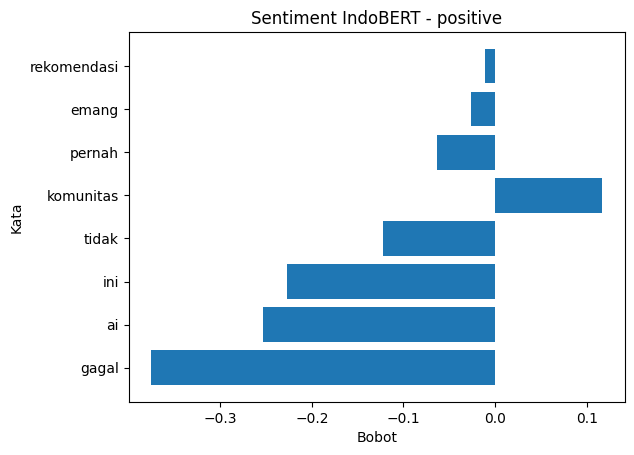

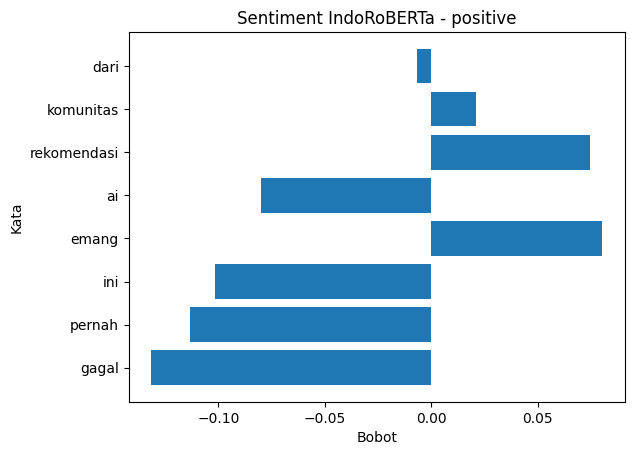


UTAUT Dominan IndoBERT: SI


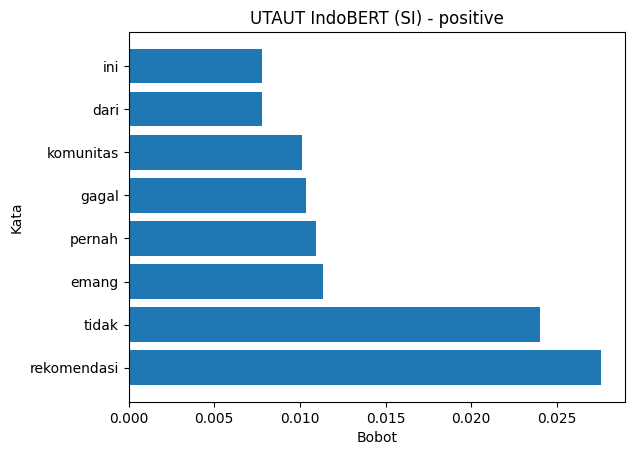

UTAUT Dominan IndoRoBERTa: SI


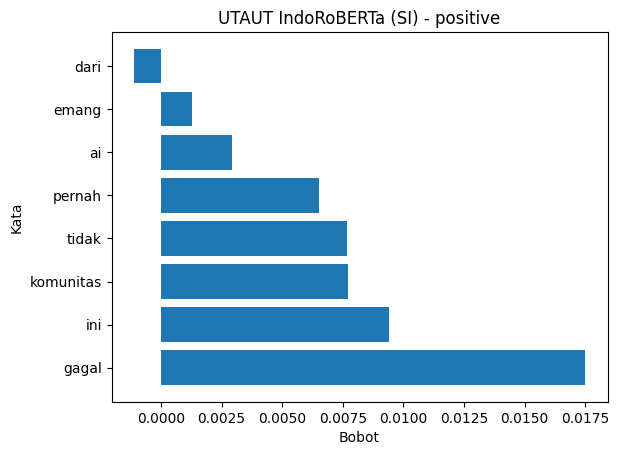


KOMENTAR (NEGATIVE): doesn't work! padahal udah lokasi us,cek pake myip atau mycountry juga us,tapi tidak ada tab video di gemini,keknya google udah fixed issue

Probabilitas IndoBERT: [0.8400365  0.15519404 0.00476951]
Probabilitas IndoRoBERTa: [0.7848736  0.20677586 0.00835065]
Label IndoBERT: 0
Label IndoRoBERTa: 0


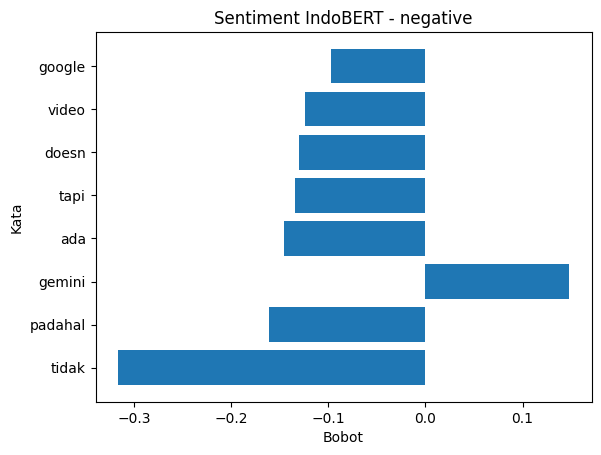

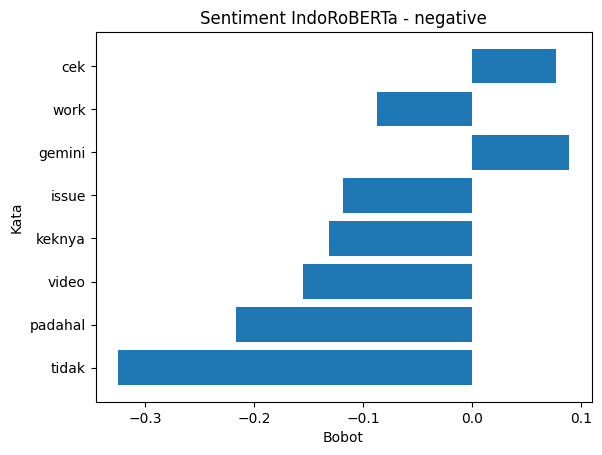


UTAUT Dominan IndoBERT: SI


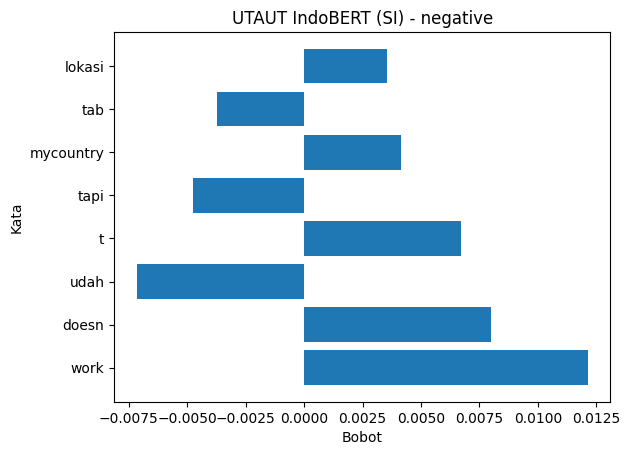

UTAUT Dominan IndoRoBERTa: SI


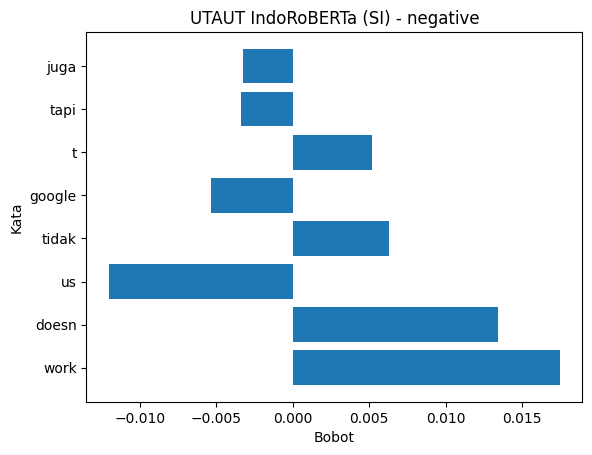


KOMENTAR (NEUTRAL): dosen saya nyaranin pake ini buat riset. koneksi internet harus stabil biar tidak gagal terus. wkwk

Probabilitas IndoBERT: [0.04741865 0.644162   0.30841938]
Probabilitas IndoRoBERTa: [0.5467883  0.21368434 0.23952734]
Label IndoBERT: 1
Label IndoRoBERTa: 0


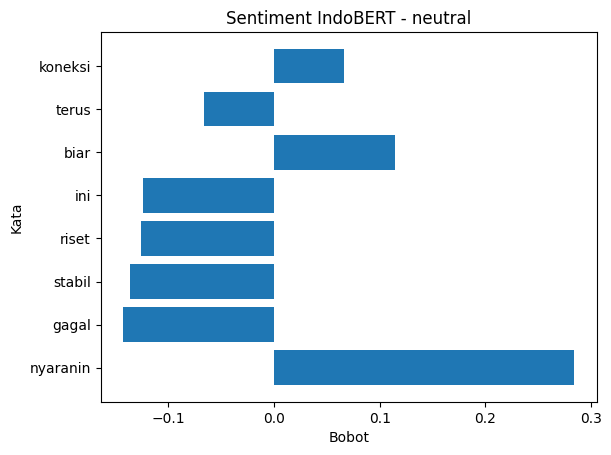

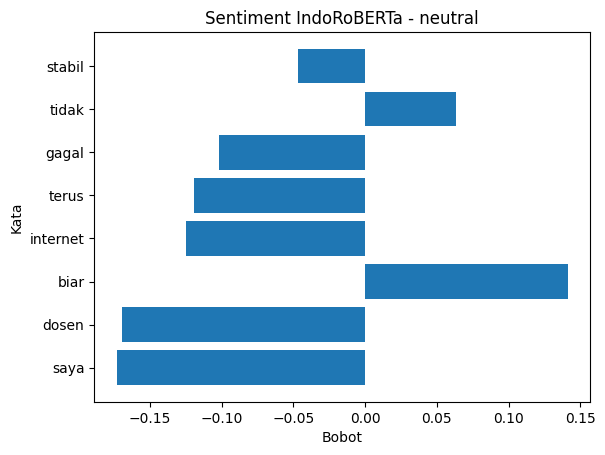


UTAUT Dominan IndoBERT: SI


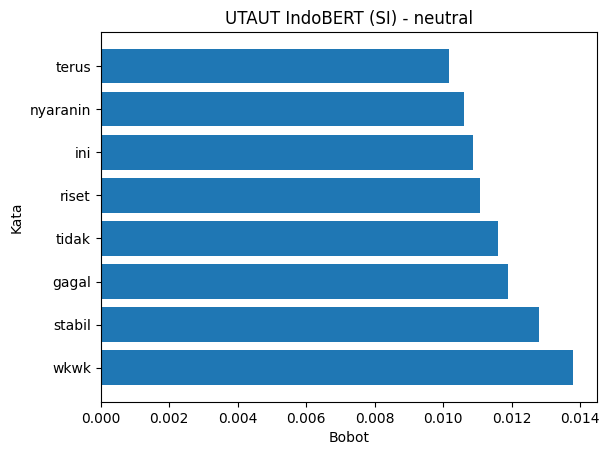

UTAUT Dominan IndoRoBERTa: SI


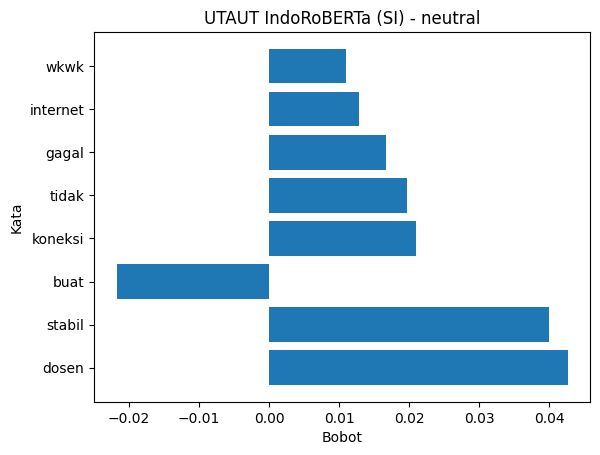

In [ ]:
# =========================================
# 🔁 LOOP UTAMA
# =========================================
for label, text in selected_texts.items():

    print("\n" + "="*70)
    print(f"KOMENTAR ({label.upper()}): {text}")
    print("="*70)

    # =========================
    # 📊 VALIDASI PREDIKSI
    # =========================
    probs_bert = predict_sentiment_bert([text])[0]
    probs_roberta = predict_sentiment_roberta([text])[0]

    print("\nProbabilitas IndoBERT:", probs_bert)
    print("Probabilitas IndoRoBERTa:", probs_roberta)

    # =========================
    # 🟢 SENTIMENT - INDOBERT
    # =========================
    exp_bert = explainer_sent.explain_instance(
        text,
        predict_sentiment_bert,
        num_features=8
    )
    plot_lime(
        exp_bert,
        f"Sentiment IndoBERT - {label}"
    )

    # =========================
    # 🔵 SENTIMENT - INDOROBERTA
    # =========================
    exp_roberta = explainer_sent.explain_instance(
        text,
        predict_sentiment_roberta,
        num_features=8
    )
    plot_lime(
        exp_roberta,
        f"Sentiment IndoRoBERTa - {label}"
    )

    # =========================
    # 🟣 UTAUT - INDOBERT (DOMINAN)
    # =========================
    probs_utaut_bert = predict_utaut_bert([text])[0]
    dominant_idx_bert = np.argmax(probs_utaut_bert)
    dominant_konsep_bert = class_names_utaut[dominant_idx_bert]

    print(f"\nUTAUT Dominan IndoBERT: {dominant_konsep_bert}")

    exp_utaut_bert = explainer_utaut.explain_instance(
        text,
        predict_utaut_bert,
        num_features=8,
        labels=[dominant_idx_bert]
    )

    plot_lime(
        exp_utaut_bert,
        f"UTAUT IndoBERT ({dominant_konsep_bert}) - {label}",
        label=dominant_idx_bert
    )

    # =========================
    # 🟠 UTAUT - INDOROBERTA (DOMINAN)
    # =========================
    probs_utaut_roberta = predict_utaut_roberta([text])[0]
    dominant_idx_roberta = np.argmax(probs_utaut_roberta)
    dominant_konsep_roberta = class_names_utaut[dominant_idx_roberta]

    print(f"UTAUT Dominan IndoRoBERTa: {dominant_konsep_roberta}")

    exp_utaut_roberta = explainer_utaut.explain_instance(
        text,
        predict_utaut_roberta,
        num_features=8,
        labels=[dominant_idx_roberta]
    )

    plot_lime(
        exp_utaut_roberta,
        f"UTAUT IndoRoBERTa ({dominant_konsep_roberta}) - {label}",
        label=dominant_idx_roberta
    )

### Hitung hasil model konstruk

In [57]:
TAM_LABELS=['PE','EE','SI','FC']
def hitung_tabel(df, model_name):

    hasil = []

    for k in TAM_LABELS:
        subset = df[df[k] > 0]

        sentiment_count = subset["sentiment"].value_counts()

        hasil.append({
            "Model": model_name,
            "Konstruk": k,
            "Positive": sentiment_count.get("positive", 0),
            "Neutral": sentiment_count.get("neutral", 0),
            "Negative": sentiment_count.get("negative", 0),
            "Rata_Skor": round(subset[k].mean(), 2) if len(subset) > 0 else 0,
            "Total": len(subset)
        })

    return pd.DataFrame(hasil)

In [58]:
tabel_indobert = hitung_tabel(df_bert, "IndoBERT")
tabel_indoroberta = hitung_tabel(df_roberta, "IndoRoBERTa")

In [59]:
df_hasil = pd.concat([tabel_indobert, tabel_indoroberta])

print(df_hasil)

         Model Konstruk  Positive  Neutral  Negative  Rata_Skor  Total
0     IndoBERT       PE      1670     1329      1013       1.00   4012
1     IndoBERT       EE      1607     3516      1731       1.15   6854
2     IndoBERT       SI      2375     2303      1867       1.51   6545
3     IndoBERT       FC      1336     2198      1003       1.07   4537
0  IndoRoBERTa       PE      1802     2728      1875       1.00   6405
1  IndoRoBERTa       EE      1221     3282      2081       1.18   6584
2  IndoRoBERTa       SI      2308     4403      2749       1.38   9460
3  IndoRoBERTa       FC      1329     2950      1716       1.06   5995
